In [5]:
# Load the required modules

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from scipy.sparse import csr_matrix
import anndata as ad

# Ignore the warning messages
warnings.filterwarnings("ignore")

### Visual comparison of marker gene expression between real and synthetic datasets

In this section, we visualize the expression of key PDAC marker genes across all cell types using **dot plots**.  
The real dataset serves as the biological reference, while the LVAE-generated dataset represents synthetic data produced by our model.

Each dot encodes two types of information:
- **Color** — the average (standardized) expression level of each gene within a cell type.  
- **Size** — the fraction of cells in that population expressing the gene.

By comparing the dot plots from the real and synthetic datasets, we can qualitatively evaluate how well the generative model reproduces biologically meaningful expression patterns across cell types.


In [3]:
marker_genes_pdac = ["REG1A", "CFTR", "DEFB1", "MMP7", "TACSTD2", "UBD", #Acinar
                     "CLDN10", "FXYD2", "SLC4A4", "AMBP", "SERPINA5", #Ductal
                     "KRT19", "MUC1", "FXYD3", "AGR2", "LGALS4", #Tumoral – Classical
                     "KRT17", "S100A2", "LAMC2", "SPARC", #Tumoral – Basal-like
                     "CHGA", "CHGB", "SCGN", "NEUROD1", "PCSK1N", #Endocrine
                     "TPSAB1", "CPA3","KIT","RGS13","SH2D6", #Mast cells
                     "HLA-DRA", "HLA-DPA1", "HLA-DRB1", "CD74", "AIF1", #Dendritic cells
                     "CD68", "TYROBP", "FCER1G", "SRGN", "FTL", #Macrophages
                     "LYZ", "LST1", "HLA-DRA", "CSTA", "LAPTM5", #Monocytes
                     "MZB1", "XBP1", "IGJ", "CD79A", "IGLL5", #Plasma cells
                     "MKI67", "TOP2A", "BIRC5", "PTTG1", "NUSAP1", #Proliferative
                     "MS4A1", "CD37", "CD79A", "LTB", "PTPRCAP", #B cell
                     "CD3E", "NKG7", "CCL5", "CD2", "SRGN", #T CD8
                     "CD3D", "IL7R", "CXCR4", "CD52", "B2M", #T CD4
                     "FOXP3", "IL2RA","CTLA4","TNFRSF18","IL32", #Treg
                     "PLVAP", "EMCN", "SPARCL1", "RAMP2", "CLEC14A", #Endothelial
                     "DCN", "LUM", "FBLN1", "COL6A2", "COL1A2", #Fibroblast
                     "ACTA2", "TAGLN", "MYL9", "SPARC", "LGALS1", #myCAF
                    ]

In [7]:
def load_and_merge(folder: str, filetype: str = ".h5ad") -> ad.AnnData:
    """
    Load and merge multiple AnnData (.h5ad) files from a given folder.

    This function scans a directory for all files with the specified extension,
    loads each one as an AnnData object, and concatenates them into a single
    AnnData object.

    Parameters
    ----------
    folder : str
        Path to the folder containing the files to load.
    filetype : str, optional
        File extension to look for (default: '.h5ad').

    Returns
    -------
    AnnData
        A single merged AnnData object containing all loaded datasets.
    """
    adatas = []
    fnames = sorted([f for f in os.listdir(folder) if f.endswith(filetype)])

    for fname in fnames:
        path = os.path.join(folder, fname)
        print(f"Loading: {path}")
        adata = sc.read(path)
        adatas.append(adata)
        
    adata_merged = ad.concat(adatas, join="outer", fill_value=0)

    return adata_merged


### ADATA REAL

In [8]:
adata = sc.read_h5ad("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/adata_raw_reanotado_peng_octubre.h5ad")
adata.obs["cell_origin"] = "real"

In [9]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalization of gene expression counts across cells
adata.layers['counts'] = csr_matrix(adata.X) 
adata.raw = adata 
sc.pp.normalize_total(adata, target_sum=1e4) 
sc.pp.log1p(adata)

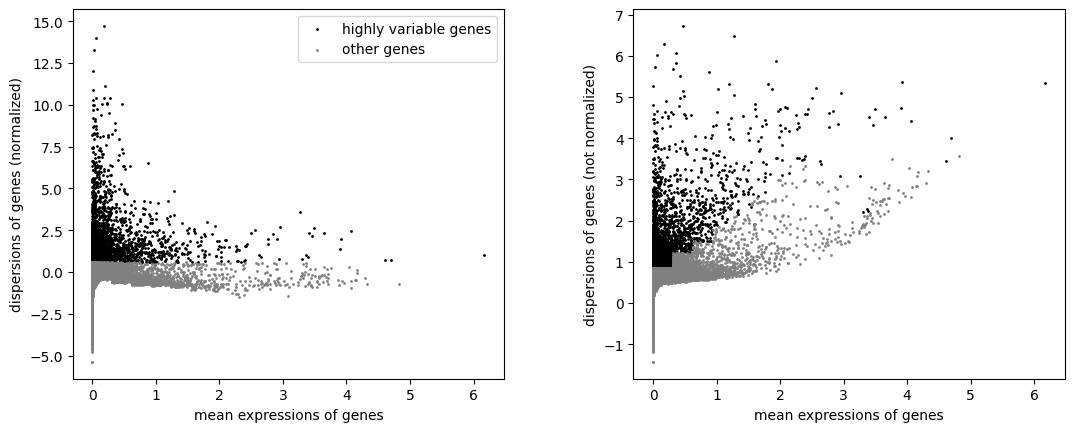

In [10]:
# Record highly variable genes (HVGs)
sc.pp.highly_variable_genes(adata,n_top_genes=3000)
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable].copy()

In [11]:
# Save list of highly variable genes (HVGs)
hvg = list(adata.var_names)

In [26]:
#Reload ADATA REAL
adata = sc.read_h5ad("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/adata_raw_reanotado_peng_octubre.h5ad")
adata.obs["cell_origin"] = "real"

In [27]:
# qc filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

#HVGs filtering
adata = adata[:, adata.var_names.isin(hvg)].copy()

In [28]:
# Normalization of gene expression counts across cells
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [29]:
###############################################################################################################

### ADATA LVAE

In [44]:
adata_lvae = load_and_merge("/home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre")
adata_lvae.obs["cell_origin"] = "synthetic"

Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/Acinar cell_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/B cell_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/CAF_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/Dendritic cells_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/Ductal cell_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/Endocrine cells_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/Endothelial cells_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos_octubre/Fibroblast_cholesky.h5ad
Loading: /home/app/ACTIVA/homo sapiens/articulo/articulo_def/figuras_final/datos

In [45]:
# Clean cell type labels in LVAE AnnData object
# Remove the suffix " Cholesky" from all cell type names to standardize nomenclature.
adata_lvae.obs["cell_type"] = (
    adata_lvae.obs["cell_type"]
    .astype(str)              
    .str.replace(" Cholesky", "", regex=False)
)

# Convert back to categorical to preserve a clean, ordered representation of cell types.
adata_lvae.obs["cell_type"] = pd.Categorical(adata_lvae.obs["cell_type"])

In [46]:
# Remove unwanted cell types from the LVAE dataset
remove_types = ["Ribosomal cells", "Proliferative cells"]
adata_lvae_filtered = adata_lvae[~adata_lvae.obs["cell_type"].isin(remove_types)].copy()


In [47]:
# Remove unwanted cell types from the REAL dataset
remove_types = ["Ribosomal cells", "Proliferative cells"]
adata_filtered = adata[~adata.obs["cell_type"].isin(remove_types)].copy()

In [48]:
###############################################################################################################

In [49]:
# Identify marker genes for each cell type
# Perform differential expression analysis to rank genes that best distinguish each cell type within the filtered dataset. 
sc.tl.rank_genes_groups(adata_filtered, "cell_type")
sc.tl.rank_genes_groups(adata_lvae_filtered, "cell_type")

In [50]:
# Compute hierarchical clustering of cell types
# Generate a dendrogram based on the similarity of average gene expression profiles across cell types. 
sc.tl.dendrogram(adata_filtered, groupby='cell_type')
sc.tl.dendrogram(adata_lvae_filtered, groupby='cell_type')

In [51]:
# Configure global Matplotlib aesthetics
# Adjust font and label sizes for improved readability across all plots.
plt.rcParams.update({
    "font.size": 18,          # Base font size
    "axes.labelsize": 18,     # Axis label font size
    "xtick.labelsize": 5,     # X-axis tick label font size
    "ytick.labelsize": 5,     # Y-axis tick label font size
    "legend.frameon": False   # Remove frame from legends for a cleaner look
})


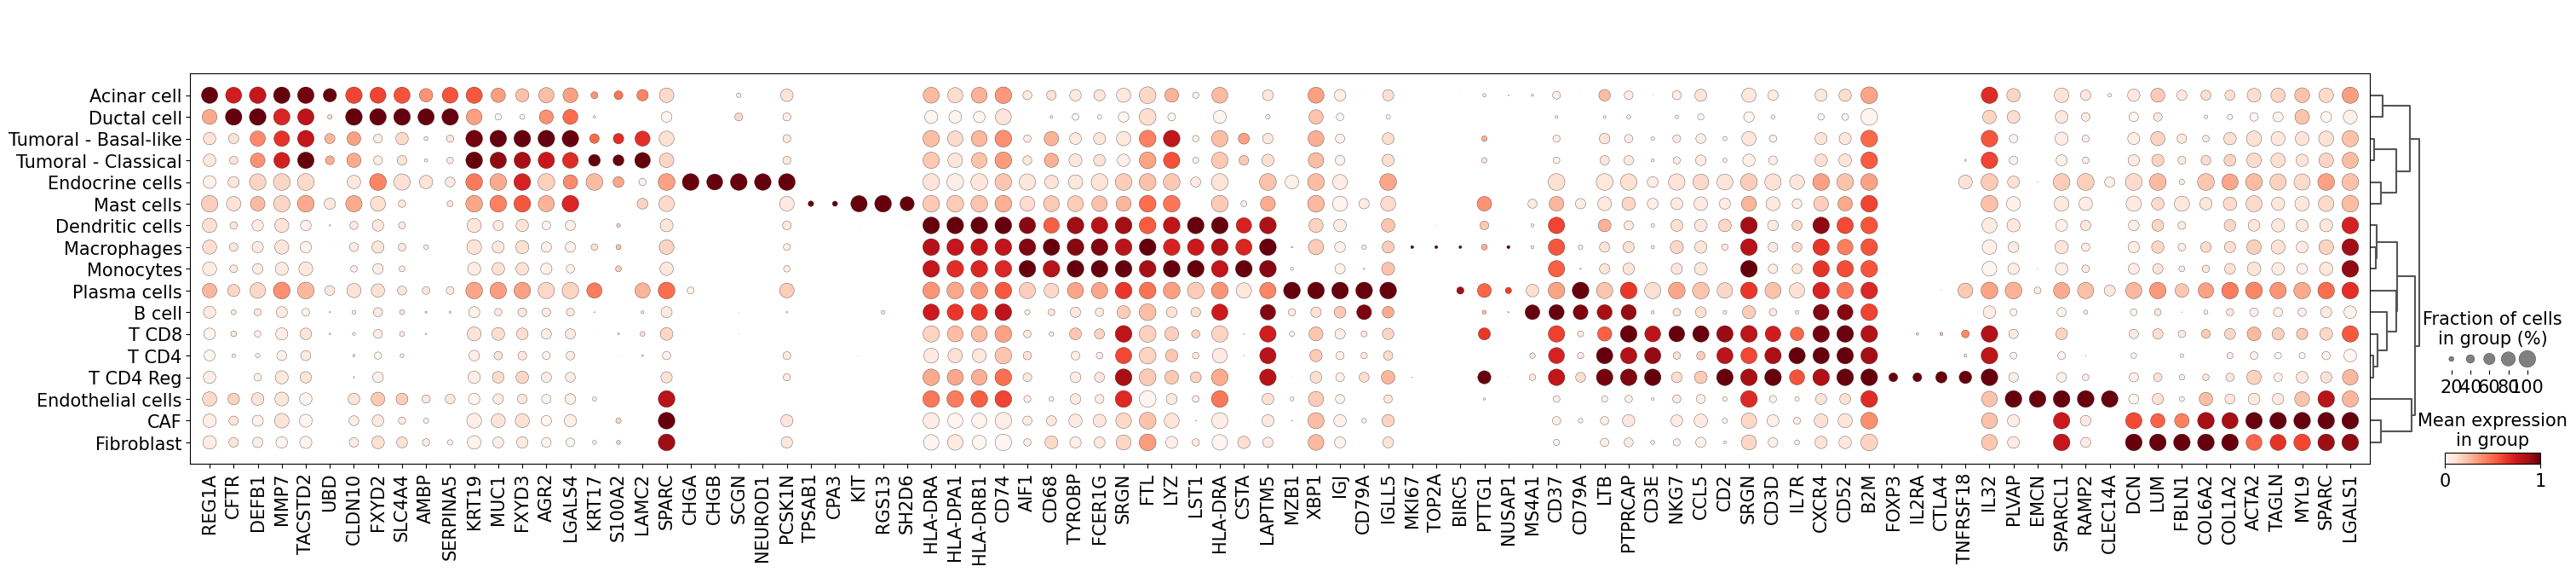

In [54]:
# Visualize marker gene expression across cell types (dotplot)
# Generate a dot plot showing the expression levels and detection rates of selected PDAC marker genes across all cell types in the LVAE-generated dataset.
# Each dot’s color indicates the standardized (z-scored) expression,
# while the dot size represents the fraction of cells expressing the gene.
# The dendrogram on top groups similar cell types based on expression patterns.

# The resulting figure is saved with the suffix "dotplot_LVAE".
sc.pl.rank_genes_groups_dotplot(
    adata_lvae_filtered,
    standard_scale="var",
    var_names=marker_genes_pdac,
    dendrogram=True,
    save="dotplot_LVAE"
)


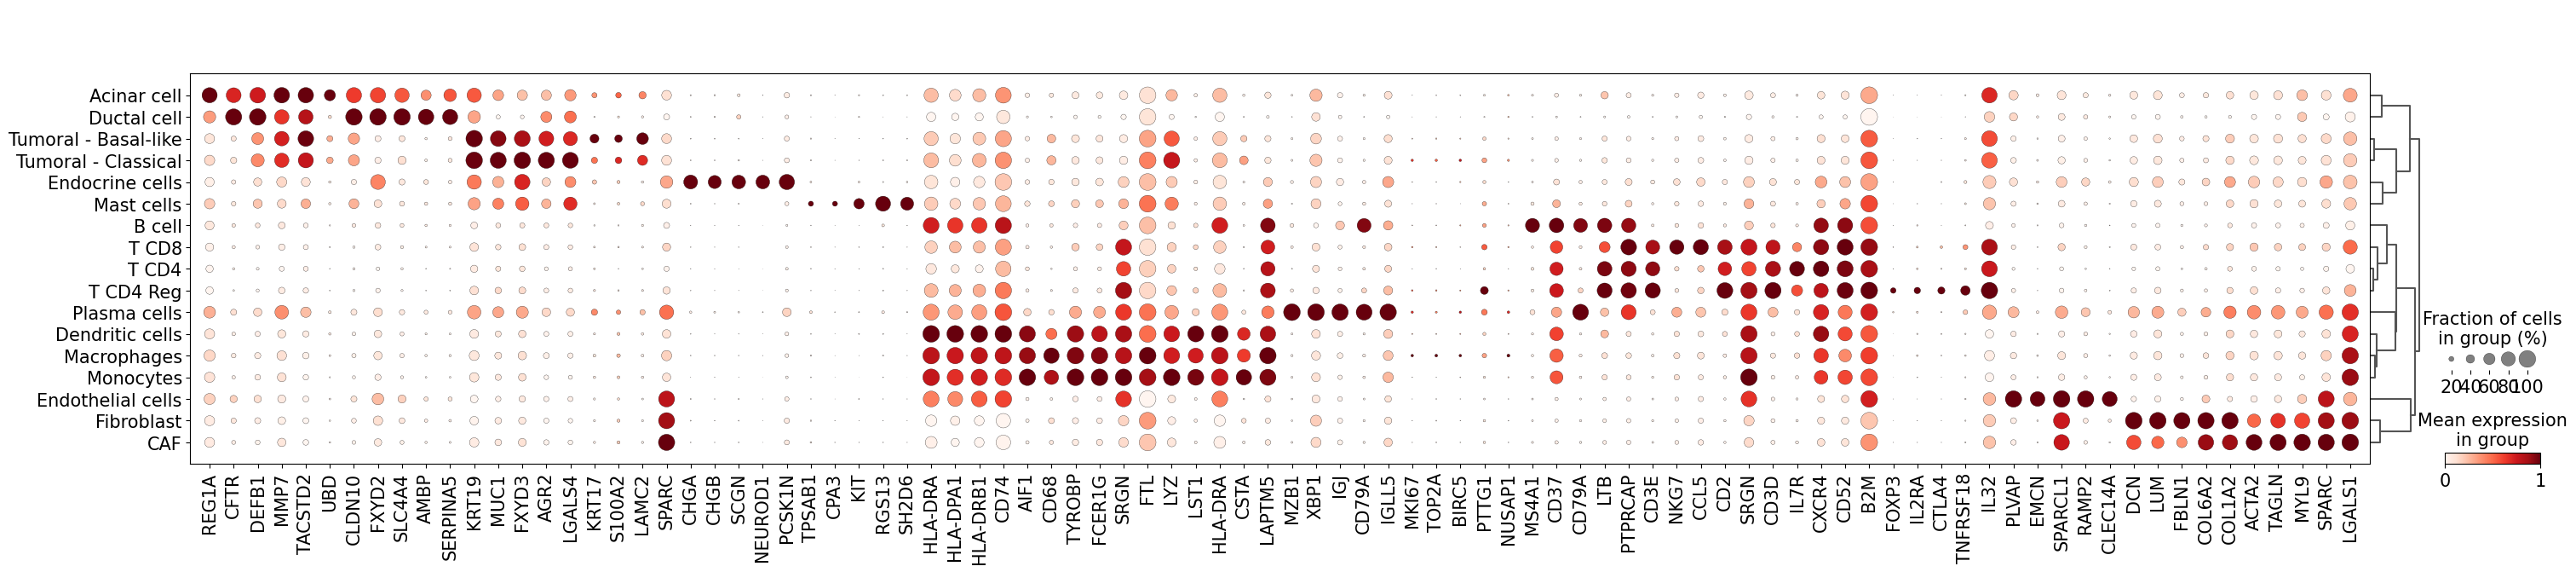

In [55]:
# Visualize marker gene expression across cell types in the real dataset
# Generate a dot plot displaying the expression levels and detection frequencies of selected PDAC marker genes across all cell types in the real dataset.
# Each dot’s color reflects the standardized (z-scored) expression value,
# while its size indicates the proportion of cells expressing that gene.
# This serves as the biological reference against which synthetic datasets.
# The figure is saved with the suffix "dotplot_real".
sc.pl.rank_genes_groups_dotplot(
    adata_filtered,
    standard_scale="var",
    var_names=marker_genes_pdac,
    save="dotplot_real"
)
